In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from models.cox_model_upd import CoxModelUpd
from models.rsf_model import RSFModel
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.evaluator import SurvivalEvaluator
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
df.info()
#print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18668 entries, 0 to 18667
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     18668 non-null  object 
 1   age                      18668 non-null  int64  
 2   sex                      18668 non-null  object 
 3   race                     18668 non-null  object 
 4   c_charge_degree          17883 non-null  object 
 5   c_charge_desc            17870 non-null  object 
 6   in_custody               18074 non-null  object 
 7   out_custody              18074 non-null  object 
 8   custody_num              18668 non-null  int64  
 9   time_to_last_custody     7797 non-null   float64
 10  time_since_last_arrest   7797 non-null   float64
 11  time_to_future_arrest    7797 non-null   float64
 12  event                    18668 non-null  int64  
 13  event_of_future_arrest   18668 non-null  int64  
 14  curr_dur_custody      

In [3]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].str.strip('()')
cox_df['race'] = cox_df['race'].str.strip('').str.upper()
cox_df['sex'] = cox_df['sex'].str.strip().str.upper()
sex_mapping = {
    'MALE': 0,
    'FEMALE': 1
}
cox_df['sex'] = cox_df['sex'].map(sex_mapping)
cox_df.head()
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    7772 non-null   object 
 1   episode_col             7772 non-null   int64  
 2   start                   7772 non-null   float64
 3   stop                    7772 non-null   float64
 4   event                   7772 non-null   int64  
 5   age                     7772 non-null   int64  
 6   sex                     7772 non-null   int64  
 7   race                    7772 non-null   object 
 8   c_charge_degree         7667 non-null   object 
 9   time_since_last_arrest  7772 non-null   float64
 10  average_dur_custody     7772 non-null   float64
 11  curr_dur_custody        7772 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 728.8+ KB


In [4]:
cox_df['race'].value_counts()

race
AFRICAN-AMERICAN    4667
CAUCASIAN           2345
HISPANIC             442
OTHER                283
NATIVE AMERICAN       21
ASIAN                 14
Name: count, dtype: int64

In [5]:
rare_threshold = 40
value_counts = cox_df['c_charge_degree'].value_counts()
rare_categories = value_counts[value_counts < rare_threshold].index.tolist()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].replace(rare_categories, 'OTHER')

Data split into train and test data

In [6]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [7]:
ohe = OneHotEncoder(
    drop='first',
    sparse_output=True,
    handle_unknown='ignore'
)

categorical_cols = ['c_charge_degree', 'race']
ohe.fit(train_df[categorical_cols])

train_encoded = ohe.transform(train_df[categorical_cols])
test_encoded = ohe.transform(test_df[categorical_cols])
train_encoded_dense = train_encoded.toarray()
test_encoded_dense = test_encoded.toarray()

encoded_cols = ohe.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(train_encoded_dense, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded_dense, columns=encoded_cols, index=test_df.index)

train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

In [8]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,sex,time_since_last_arrest,average_dur_custody,time,...,c_charge_degree_M1,c_charge_degree_M2,c_charge_degree_MO3,c_charge_degree_OTHER,c_charge_degree_nan,race_ASIAN,race_CAUCASIAN,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER
1171,daniel diaz,1,0.0,104.0,1,50,0,70.0,34.00,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1172,daniel diaz,2,104.0,159.0,1,50,0,24.0,32.50,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1173,daniel diaz,3,159.0,235.0,1,50,0,12.0,43.00,76.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1174,daniel diaz,4,235.0,261.0,1,50,0,25.0,32.50,26.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1175,daniel diaz,5,261.0,391.0,1,50,0,12.0,49.60,130.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1176,daniel diaz,6,391.0,1079.0,1,50,0,509.0,71.17,688.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1177,daniel diaz,7,1079.0,1088.0,1,50,0,7.0,61.29,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1178,daniel diaz,8,1088.0,1128.0,0,50,0,6.0,57.88,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]]

cols_for_model = ["name", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

In [10]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     3382
2     1503
3      680
4      304
5      148
6       77
7       37
8       11
9        5
10       2
dtype: int64

episode_col
1     845
2     435
3     184
4      78
5      34
6      16
7      13
8       5
9       4
10      4
11      3
12      2
dtype: int64

In [11]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [12]:
horizon = np.quantile(train_model_df["stop"] - train_model_df["start"], 0.95)
times = np.linspace(0, horizon, 200)

In [13]:
# models = {}

# for model_mode in ["recurrent", "independent"]:
#     for use_episode in [True, False]:
#         for penalizer in [0.0, 0.01, 0.1]:
#             name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
#             print(name)
#             features_model = features.copy()
#             if not(use_episode):
#                 features_model.remove("episode_col")

#             model = CoxModelUpd(
#                 features=features_model,
#                 mode=model_mode,
#                 use_episode=use_episode,
#                 penalizer=penalizer    
#             )
#             if model_mode == "recurrent":
#                 model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
#             else:
#                 model.fit(train_model_df[features_model + ["time", "event"]])
#             model.features = features_model
#             models[name] = model

# features_rsf = features.copy()
# features_rsf.remove("episode_col")
# train_rsf_df = train_df[["time","event"] + features_rsf].copy()
# rsf_model = RSFModel(features=features_rsf)
# rsf_model.fit(train_rsf_df)
# rsf_model.features = features_rsf
# models["RSF_no_episode_col"] = rsf_model

In [14]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "RSF_ind": {'model': RSFModel, 'mode': 'independent',
                'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2, 10]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.0_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-15215.27


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.0_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-19036.38
time fit was run,2026-03-18 16:58:28 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20500.60
         time fit was run = 2026-03-18 16:58:36 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
episode_col             0.03      1.03      0.01           -0.00            0.05                1.00                1.06
age                    -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
sex                    -0.06      0.95      0.05           -0.15            0.04                0.86                1.04
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
c_charge_degree_F2     -0.13      0.88      0.08           -0.27            0.02                0.76                1.02
c_charge_degree_F3      0.08      1.09      0.06           -0.03            0.19                0.97                1.21
c_charge_degree_F7      0.01      1.01      0.18           -0.34            0.36                0.71                1.43
c_charge_degree_M1     -0.08      0.93      0.07           -0.21            0.05                0.81                1.06
c_charge_degree_M2     -0.04      0.96      0.08           -0.20            0.12                0.82                1.13
c_charge_degree_MO3     0.35      1.42      0.19           -0.02            0.72                0.98                2.05
c_charge_degree_OTHER   0.12      1.13      0.33           -0.52            0.76                0.60                2.14
c_charge_degree_nan     0.32      1.38      0.15            0.02            0.62                1.02                1.86
race_ASIAN             -0.77      0.47      0.64           -2.03            0.50                0.13                1.65
race_CAUCASIAN         -0.08      0.92      0.04           -0.16           -0.01                0.85                0.99
race_HISPANIC          -0.20      0.82      0.08           -0.35           -0.04                0.70                0.96
race_NATIVE AMERICAN    0.20      1.22      0.41           -0.62            1.01                0.54                2.74
race_OTHER             -0.10      0.90      0.10           -0.29            0.09                0.74                1.10

                        cmp to      z      p  -log2(p)
covariate                                             
episode_col               0.00   1.78   0.07      3.74
age                       0.00  -3.21 <0.005      9.57
sex                       0.00  -1.14   0.26      1.97
time_since_last_arrest    0.00 -49.78 <0.005       inf
average_dur_custody       0.00 -34.15 <0.005    846.66
c_charge_degree_F2        0.00  -1.69   0.09      3.46
c_charge_degree_F3        0.00   1.49   0.14      2.87
c_charge_degree_F7        0.00   0.05   0.96      0.06
c_charge_degree_M1        0.00  -1.15   0.25      1.99
c_charge_degree_M2        0.00  -0.46   0.65      0.63
c_charge_degree_MO3       0.00   1.87   0.06      4.01
c_charge_degree_OTHER     0.00   0.37   0.71      0.49
c_charge_degree_nan       0.00   2.11   0.04      4.83
race_ASIAN                0.00  -1.19   0.24      2.09
race_CAUCASIAN            0.00  -2.11   0.03      4.86
race_HISPANIC             0.00  -2.47   0.01      6.22
race_NATIVE AMERICAN      0.00   0.47   0.64      0.65
race_OTHER                0.00  -1.01   0.31      1.68
---
Concordance = 0.93
Partial AIC = 41037.20
log-li

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20502.16
         time fit was run = 2026-03-18 16:58:36 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
sex                    -0.06      0.94      0.05           -0.15            0.04                0.86                1.04
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
c_charge_degree_F2     -0.13      0.88      0.08           -0.28            0.02                0.76                1.02
c_charge_degree_F3      0.09      1.09      0.06           -0.03            0.20                0.98                1.22
c_charge_degree_F7      0.00      1.00      0.18           -0.35            0.36                0.71                1.43
c_charge_degree_M1     -0.08      0.92      0.07           -0.21            0.05                0.81                1.05
c_charge_degree_M2     -0.04      0.96      0.08           -0.20            0.12                0.82                1.13
c_charge_degree_MO3     0.35      1.42      0.19           -0.01            0.72                0.99                2.06
c_charge_degree_OTHER   0.11      1.12      0.33           -0.53            0.75                0.59                2.12
c_charge_degree_nan     0.33      1.39      0.15            0.03            0.62                1.03                1.87
race_ASIAN             -0.78      0.46      0.64           -2.04            0.48                0.13                1.62
race_CAUCASIAN         -0.09      0.92      0.04           -0.16           -0.01                0.85                0.99
race_HISPANIC          -0.20      0.82      0.08           -0.36           -0.05                0.70                0.95
race_NATIVE AMERICAN    0.19      1.21      0.41           -0.62            1.00                0.54                2.73
race_OTHER             -0.10      0.90      0.10           -0.30            0.09                0.74                1.10

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -3.30 <0.005      9.99
sex                       0.00  -1.16   0.25      2.02
time_since_last_arrest    0.00 -50.44 <0.005       inf
average_dur_custody       0.00 -34.32 <0.005    854.90
c_charge_degree_F2        0.00  -1.73   0.08      3.58
c_charge_degree_F3        0.00   1.52   0.13      2.95
c_charge_degree_F7        0.00   0.03   0.98      0.03
c_charge_degree_M1        0.00  -1.18   0.24      2.06
c_charge_degree_M2        0.00  -0.46   0.65      0.63
c_charge_degree_MO3       0.00   1.88   0.06      4.06
c_charge_degree_OTHER     0.00   0.35   0.73      0.46
c_charge_degree_nan       0.00   2.14   0.03      4.96
race_ASIAN                0.00  -1.21   0.23      2.14
race_CAUCASIAN            0.00  -2.19   0.03      5.13
race_HISPANIC             0.00  -2.54   0.01      6.51
race_NATIVE AMERICAN      0.00   0.46   0.64      0.64
race_OTHER                0.00  -1.03   0.30      1.72
---
Concordance = 0.93
Partial AIC = 41038.32
log-likelihood ratio test = 3046.51 on 17 df
-log2(p) of ll-ratio test = inf

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_False
RSF_ind_min_samples_split_10_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_10_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_10_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_10_n_estimators_200_use_episode_False


In [15]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.0_use_episode_True,0.3138,0.5813,0.5085,1.3462,0.6989,0.5747,0.4983
1,CoxUpd_rec_penalizer_0.0_use_episode_False,0.1762,0.6133,0.9252,0.6720,0.7359,0.6894,0.6004
2,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2628,0.5920,0.5036,1.0567,0.7086,0.5829,0.4935
3,CoxUpd_rec_penalizer_0.1_use_episode_False,0.1731,0.6095,0.9183,0.5876,0.7443,0.6965,0.6030
4,CoxUpd_ind_penalizer_0.0_use_episode_True,0.0352,0.7937,0.9212,1.4057,0.7135,0.6751,0.5986
5,CoxUpd_ind_penalizer_0.0_use_episode_False,0.0354,0.7915,0.9269,1.3892,0.7158,0.6768,0.5985
6,CoxUpd_ind_penalizer_0.1_use_episode_True,0.0587,0.6782,0.9227,0.8344,0.7405,0.6927,0.6029
7,CoxUpd_ind_penalizer_0.1_use_episode_False,0.0586,0.6783,0.9232,0.8485,0.7401,0.6919,0.6029
8,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0640,0.7299,0.9073,0.5283,0.7461,0.6901,0.6033
9,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0562,0.7470,0.9149,0.5007,0.7459,0.6873,0.6020


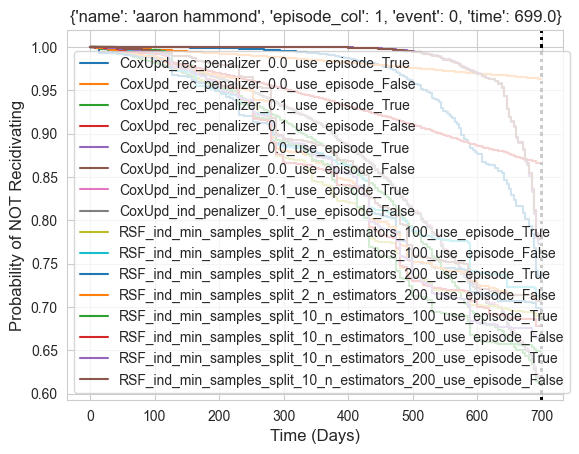

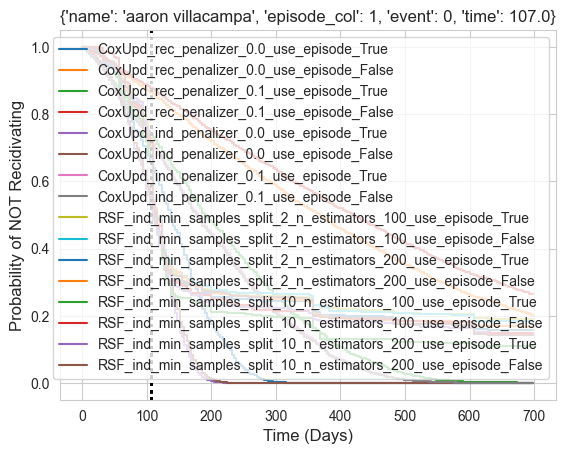

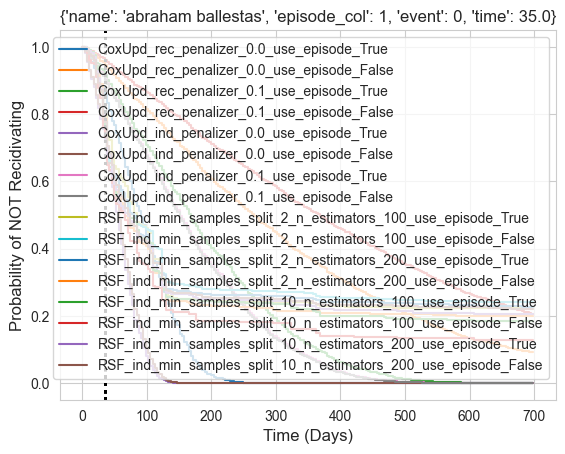

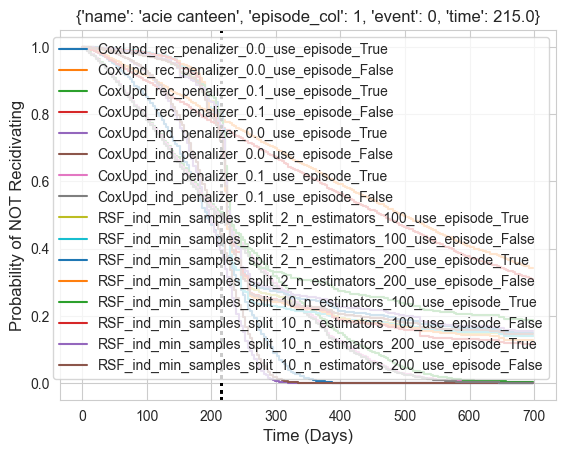

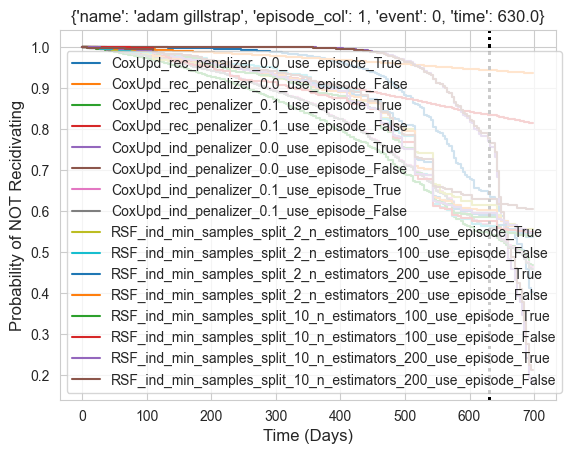

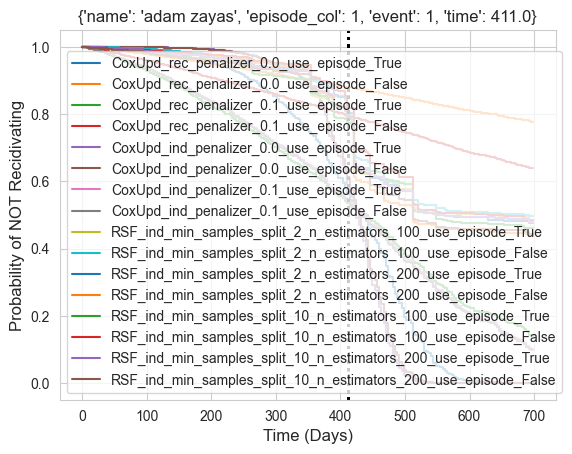

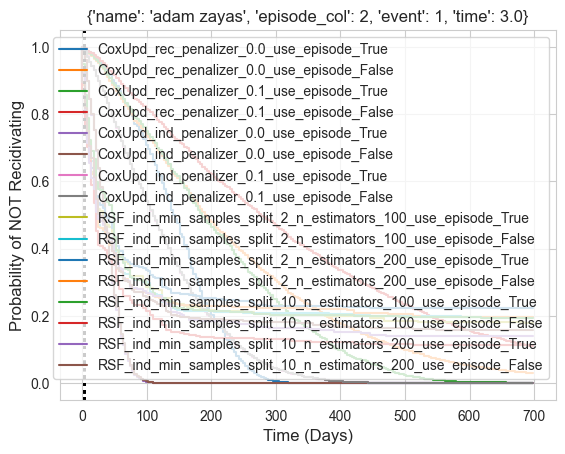

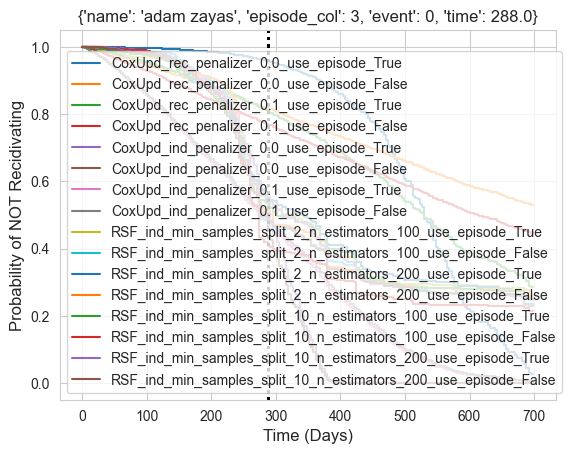

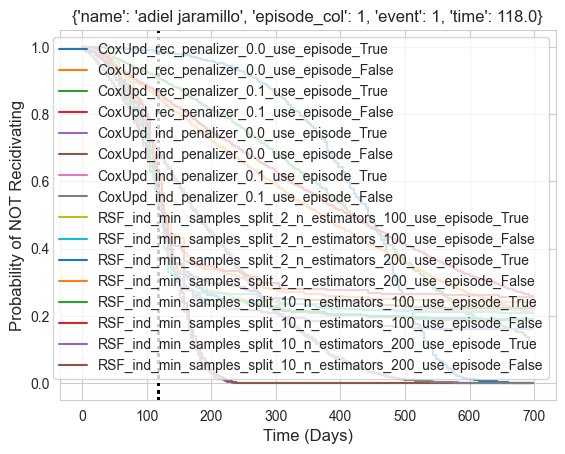

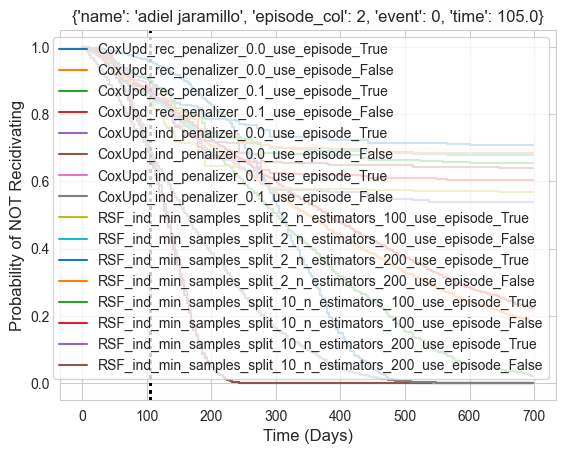

In [16]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        sample_info = test_model_df.iloc[index_test]
        event_status = "Recidivated" if sample_info["event"] == 1 else "No Recidivism"
        time_to_event = sample_info["time"]
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )
    # pred = rsf_model.predict_survival(test_model_df[rsf_model.features], times)
    # plt.step(times, pred.iloc[index_test].values, label="RSF_no_episode_col", color="red", linewidth=2)
    # sample_info = test_model_df.iloc[index_test]
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Recidivating", fontsize=12)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()